In [2]:
# Graphing tool
!pip install numpy matplotlib
import random
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [3]:
# Visualization tool
!pip install graphviz
from graphviz import Digraph
def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root, format='svg', rankdir='LR'):
    """
    format: png | svg | ...
    rankdir: TB (top to bottom graph) | LR (left to right)
    """
    assert rankdir in ['LR', 'TB']
    nodes, edges = trace(root)
    dot = Digraph(format=format, graph_attr={'rankdir': rankdir})

    for n in nodes:
        dot.node(name=str(id(n)), label="{ data %.4f | grad %.4f }" % (n.data, n.grad), shape='record')
        if n._op:
            dot.node(name=str(id(n)) + n._op, label=n._op)
            dot.edge(str(id(n)) + n._op, str(id(n)))

    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [4]:
import math

class Value:
    def __init__(self, value, _parents=(), _op='', name=''):
        self.value = value
        self.data = value
        self.grad = 0
        self._backward = lambda: None
        self._prev = set(_parents)
        self._op = _op
        self.name = name

    def __repr__(self):
        return f"V:{self.value} G:{self.grad}"

    def __add__(self, other):
        out = Value(self.value + other.value, (self, other), '+')

        def _backward():
            self.grad += out.grad * 1
            other.grad += out.grad * 1

        out._backward = _backward
        return out

    def __sub__(self, other):
        out = Value(self.value - other.value, (self, other), '-')

        def _backward():
            self.grad += out.grad * 1
            other.grad += out.grad * (-1)

        out._backward = _backward
        return out

    def __mul__(self, other):
        out = Value(self.value * other.value, (self, other), '*')

        def _backward():
            self.grad += other.value * out.grad
            other.grad += self.value * out.grad

        out._backward = _backward
        return out

    def __pow__(self, value: int | float):
        out = Value(self.value ** value, (self,), f'**{value}')

        def _backward():
            self.grad += value * (self.value ** (value - 1)) * out.grad

        out._backward = _backward
        return out

    def __truediv__(self, other):
        out = Value(self.value * (other.value ** (-1)), (self, other), f'/{other.value}')

        def _backward():
            self.grad += other.value ** (-1) * out.grad
            other.grad += (-1) * (self.value * (other.value ** (-2))) * out.grad

        out._backward = _backward
        return out

    def __rtruediv__(self, other):
        out = Value(other.value * (self.value ** (-1)), (self, other), f'{other.value}/{self.value}')

        def _backward():
            self.grad += (-1) * (other.value * (self.value ** (-2))) * out.grad
            other.grad += (self.value ** (-1)) * out.grad

        out._backward = _backward
        return out

    def relu(self):
        out = Value(0 if self.value < 0 else self.value, (self,), 'ReLU')

        def _backward():
            self.grad += (out.value > 0) * out.grad

        out._backward = _backward
        return out

    def topo_sort(self):
        topo = []
        visited = set()

        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)

        build_topo(self)
        return topo

    def backward(self):
        topo = self.topo_sort()
        self.grad = 1
        for node in reversed(topo):
            node._backward()

    def zero_grads(self):
        topo = self.topo_sort()
        for node in topo:
            node.grad = 0

    def __rpow__(self, value: int | float):
        out = Value(value ** self.value, (self,), f'exp({self.value})')

        def _backward():
            self.grad += value ** self.value * out.grad * math.log(value)

        out._backward = _backward
        return out

    def log(self):
        out = Value(math.log(self.value), (self,), 'log')

        def _backward():
            self.grad += (1 / self.value) * out.grad

        out._backward = _backward
        return out

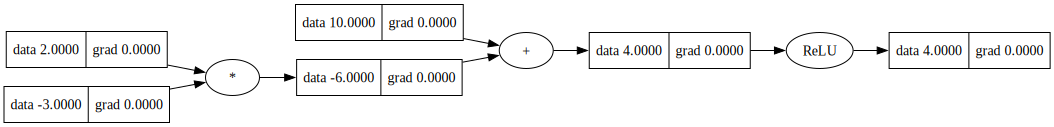

In [5]:
a = Value(2.0, name='a')
b = Value(-3.0, name='b')
c = Value(10.0, name='c')

d = a * b
d.name = 'd'
e = d + c
e.name = 'e'
L = e.relu()
L.name = 'L'

draw_dot(L)

V:2.0 G:-3.0
V:-3.0 G:2.0
V:10.0 G:1
V:4.0 G:1


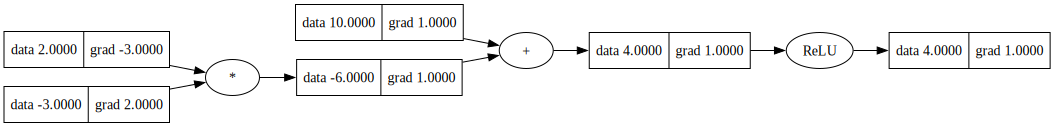

In [6]:
L.backward()
print(a)
print(b)
print(c)
print(L)

draw_dot(L)

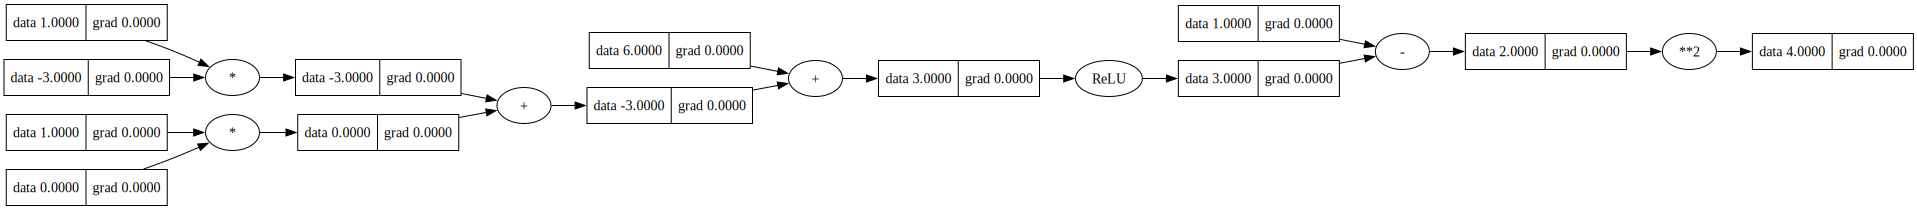

In [7]:
x1 = Value(1.0, name='x1')
x2 = Value(0.0, name='x2')
w1 = Value(-3.0, name='w1')
w2 = Value(1.0, name='w2')
bias = Value(6.0, name='b')
target = Value(1.0, name='target')

n = x1 * w1 + x2 * w2 + bias
n.name = 'n'
o = n.relu()
o.name = 'o'
loss = (o - target) ** 2
loss.name = 'loss'

draw_dot(loss)

before update: 4.0
w1 grad: 4.0 w2 grad: 0.0 b grad: 4.0
after update: 1.4399999999999993


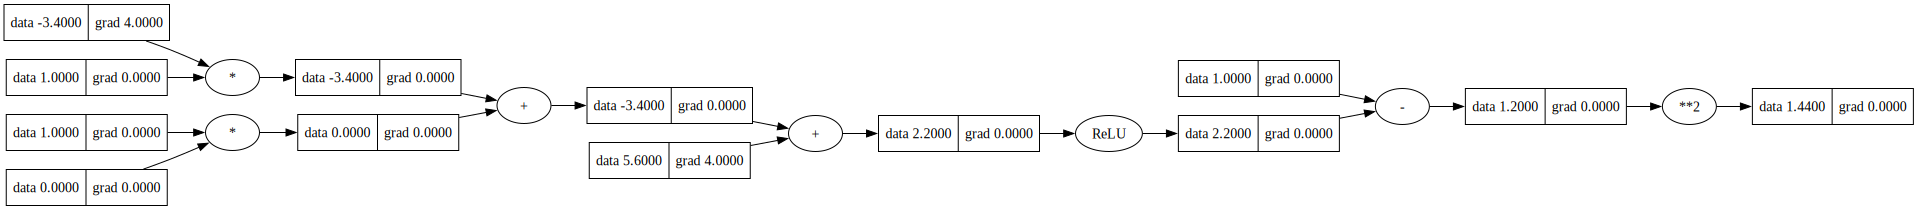

In [8]:
loss.backward()
print('before update:', loss.value)
print('w1 grad:', w1.grad, 'w2 grad:', w2.grad, 'b grad:', bias.grad)

lr = 0.1
for p in [w1, w2, bias]:
    p.value -= lr * p.grad
    p.data = p.value

x1_new = Value(1.0, name='x1_new')
x2_new = Value(0.0, name='x2_new')
target_new = Value(1.0, name='target_new')

n_new = x1_new * w1 + x2_new * w2 + bias
n_new.name = 'n_new'
o_new = n_new.relu()
o_new.name = 'o_new'
loss_new = (o_new - target_new) ** 2
loss_new.name = 'loss_new'

print('after update:', loss_new.value)
draw_dot(loss_new)